In [1]:
# Importar librerías

import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [2]:
# Conectar con la cuenta de Google Drive con el entorno de Python

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Carga el dataset csv

df_csv = pd.read_csv('/content/drive/MyDrive/data/Teen_Mental_Health_Dataset.csv')

df_csv.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [4]:
# Información del dataset csv

print(df_csv.info())

print(df_csv.describe())

print(df_csv.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB
None

In [5]:
#Limpieza de csv

df_csv_limpio = df_csv.dropna()

print("Filas originales:", df_csv.shape)
print("Filas limpias:", df_csv_limpio.shape)

Filas originales: (1200, 13)
Filas limpias: (1200, 13)


In [6]:
# Conexión con la base de datos

conexion = sqlite3.connect('/content/drive/MyDrive/data/mental_health.sqlite')

cursor = conexion.cursor()

In [7]:
# Consultas SQL para obtener tablas de SQLite

query = """
SELECT *
FROM Answer
"""

df_sql = pd.read_sql_query(query, conexion)

df_sql.head()

,AnswerText,SurveyID,UserID,QuestionID
0,37,2014,1,1
1,44,2014,2,1
2,32,2014,3,1
3,31,2014,4,1
4,31,2014,5,1


In [8]:
# Asignación de identificador de encuesta (SurveyID)

df_csv['SurveyID'] = 2019

In [9]:
# Realiza una unión (merge) entre dos DataFrames de pandas: df_csv y df_sql, utilizando la columna SurveyID como clave en común.

df_unido = pd.merge(
    df_csv,
    df_sql,
    on='SurveyID',
    how='inner'
)

df_unido.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,SurveyID,AnswerText,UserID,QuestionID
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,2019,25,3867,1
1,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,2019,51,3868,1
2,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,2019,27,3869,1
3,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,2019,37,3870,1
4,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,2019,46,3871,1


In [10]:
# print(df_unido.info())

# print(df_unido.shape)

In [11]:
# Consultas SQL para obtener tablas de SQLite

query = """
SELECT *
FROM Survey
"""

# cargar datos en pandas
df_sql = pd.read_sql_query(query, conexion)

# mostrar datos
df_sql.head()

,SurveyID,Description
0,2014,mental health survey for 2014
1,2016,mental health survey for 2016
2,2017,mental health survey for 2017
3,2018,mental health survey for 2018
4,2019,mental health survey for 2019


In [12]:
# Consultas SQL para obtener tablas de SQLite

query = """
SELECT SurveyID, COUNT(*) as total_respuestas
FROM Answer
GROUP BY SurveyID
"""

df_respuestas = pd.read_sql_query(query, conexion)

print(df_respuestas)

   SurveyID  total_respuestas
0      2014             32760
1      2016             88238
2      2017             57456
3      2018             31692
4      2019             26752


In [16]:
# Consultas SQL para obtener tablas de SQLite

query = """
SELECT SurveyID, COUNT(*) as total
FROM Answer
GROUP BY SurveyID
"""

df_pie = pd.read_sql_query(query, conexion)

print(df_pie)

   SurveyID  total
0      2014  32760
1      2016  88238
2      2017  57456
3      2018  31692
4      2019  26752


In [14]:
#Información general del dataset SQLite

print(df_sql.info())

print(df_sql.describe())

print(df_sql.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   SurveyID     5 non-null      int64 
 1   Description  5 non-null      object
dtypes: int64(1), object(1)
memory usage: 212.0+ bytes
None
          SurveyID
count     5.000000
mean   2016.800000
std       1.923538
min    2014.000000
25%    2016.000000
50%    2017.000000
75%    2018.000000
max    2019.000000
SurveyID       0
Description    0
dtype: int64


In [20]:
# Nombres o encabezados de todas las columnas del DataFrame df_unido

print(df_unido.columns.tolist())

['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label', 'SurveyID', 'AnswerText', 'UserID', 'QuestionID']


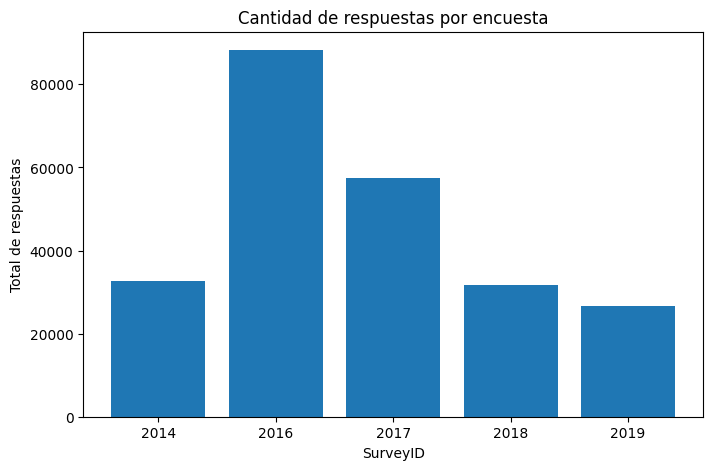

In [21]:
# Gráfico de barras de la cantidad de respuestas por encuesta

plt.figure(figsize=(8,5))

plt.bar(
    df_respuestas['SurveyID'].astype(str),
    df_respuestas['total_respuestas']
)

plt.title('Cantidad de respuestas por encuesta')
plt.xlabel('SurveyID')
plt.ylabel('Total de respuestas')

plt.show()

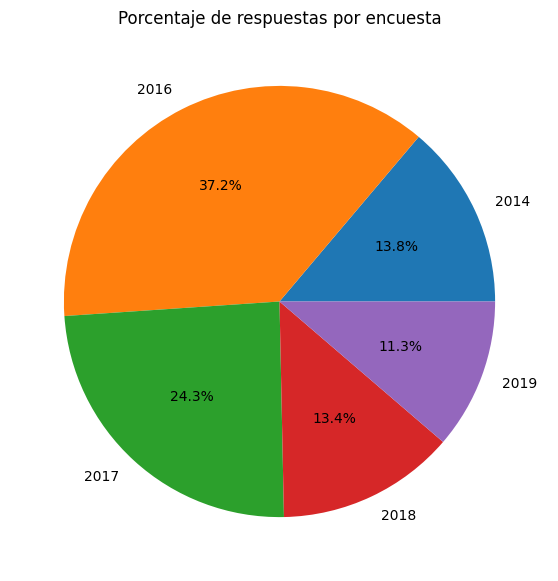

In [22]:
# Gráfico circular del porcentaje de respuesta por encuesta

plt.figure(figsize=(7,7))

plt.pie(
    df_pie['total'],
    labels=df_pie['SurveyID'],
    autopct='%1.1f%%'
)

plt.title('Porcentaje de respuestas por encuesta')

plt.show()

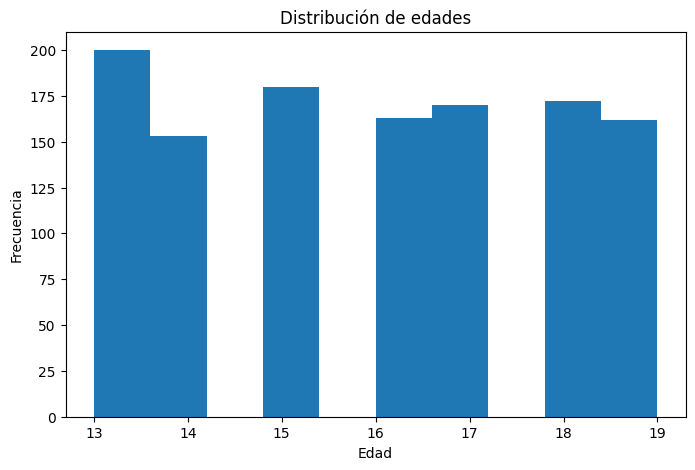

In [23]:
# Gráfico de Histograma de la distribución de edades

plt.figure(figsize=(8,5))

plt.hist(
    df_csv_limpio['age'],
    bins=10
)

plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

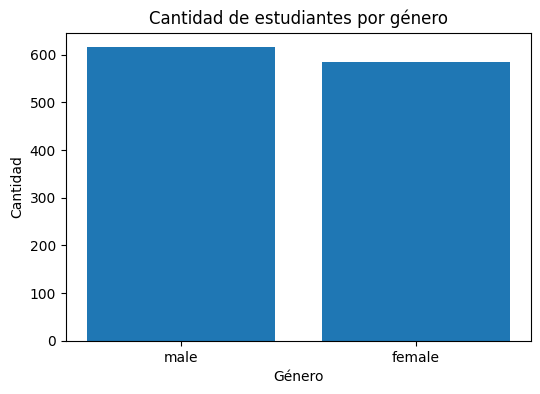

In [24]:
# Gráfico de cantidad por género

genero = df_csv_limpio['gender'].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    genero.index,
    genero.values
)

plt.title('Cantidad de estudiantes por género')
plt.xlabel('Género')
plt.ylabel('Cantidad')

plt.show()

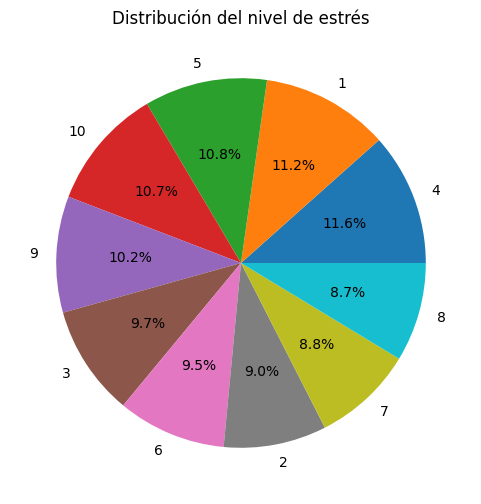

In [25]:
# Gráfico de nivel de estrés

estres = df_csv_limpio['stress_level'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    estres.values,
    labels=estres.index,
    autopct='%1.1f%%'
)

plt.title('Distribución del nivel de estrés')

plt.show()

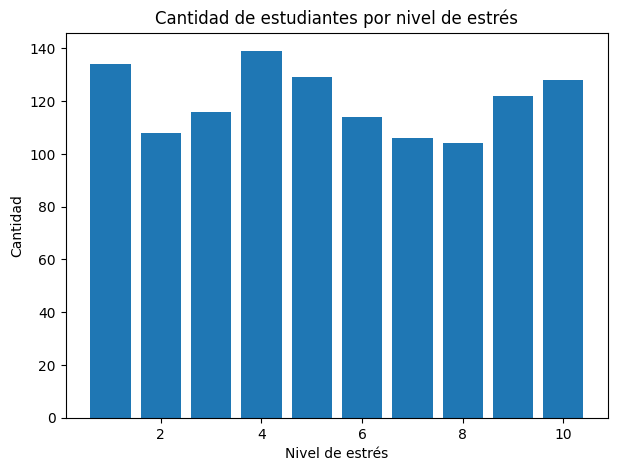

In [26]:
#Gráfico de barras de la cantidad de estudiantes por nivel de estrés

estres = df_csv_limpio['stress_level'].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    estres.index,
    estres.values
)

plt.title('Cantidad de estudiantes por nivel de estrés')
plt.xlabel('Nivel de estrés')
plt.ylabel('Cantidad')

plt.show()

In [27]:
# Guardar

df_csv_limpio.to_csv(
    'dataset_final.csv',
    index=False
)

print("Dataset final exportado correctamente")

Dataset final exportado correctamente


In [28]:
# Exportar

with open('database.sql', 'w') as f:
    for line in conexion.iterdump():
        f.write('%s\n' % line)

print("Archivo SQL exportado")

Archivo SQL exportado


In [29]:
#Descargar archivos finales

from google.colab import files

files.download('dataset_final.csv')

files.download('database.sql')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>